In [1]:
import os
os.environ['KAGGLE_USERNAME']='latchmana'
os.environ['KAGGLE_KEY']='KGAT_313c41862e108f7cdade9aa5c178414b'

In [2]:
!kaggle datasets download -d 'tejalaveti2306/health-insurance-claims-data-for-fraud-detection'



Dataset URL: https://www.kaggle.com/datasets/tejalaveti2306/health-insurance-claims-data-for-fraud-detection
License(s): CC0-1.0
100% 1.32M/1.32M [00:00<00:00, 2.43MB/s]



In [3]:
!unzip health-insurance-claims-data-for-fraud-detection

Archive:  health-insurance-claims-data-for-fraud-detection.zip
  inflating: synthetic_health_claims.csv  


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

import joblib

In [5]:
df = pd.read_csv('/content/synthetic_health_claims.csv')
df.head()

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
0,67349080,XAI956194550,18874,2021-06-16,2021-05-01,2024-11-20,462337.48,28,Female,Houston,...,Rehab/Skilled Nursing,47,Inpatient,3440.06,824.59,0,16,939.08,True,False
1,85973291,XAI215993963,8762,2025-01-19,2025-01-17,2029-04-07,1883481.30,40,Other,Washington,...,Deceased,0,Outpatient,3618.40,851.43,0,6,170.40,False,True
2,62454860,XAI146653263,1920,2023-05-05,2023-03-24,2024-09-04,1500658.89,90,Female,Seattle,...,Deceased,0,Pharmacy,2442.41,616.23,0,2,549.38,True,False
3,58632240,XAI216596381,1316,2021-11-07,2021-11-02,2025-12-24,572237.61,49,Other,Fort Worth,...,Deceased,0,Pharmacy,587.78,459.33,0,2,396.49,False,True
4,96347311,XAI056900359,17039,2024-03-25,2024-02-18,2028-07-30,2088293.84,24,Female,New York,...,Deceased,0,Emergency Room,3047.55,847.40,0,15,865.87,True,False


In [6]:
df.shape

(20100, 30)

In [7]:
df.columns

Index(['Patient_ID', 'Policy_Number', 'Claim_ID', 'Claim_Date', 'Service_Date',
       'Policy_Expiration_Date', 'Claim_Amount', 'Patient_Age',
       'Patient_Gender', 'Patient_City', 'Patient_State', 'Hospital_ID',
       'Provider_Type', 'Provider_Specialty', 'Provider_City',
       'Provider_State', 'Diagnosis_Code', 'Procedure_Code',
       'Number_of_Procedures', 'Admission_Type', 'Discharge_Type',
       'Length_of_Stay_Days', 'Service_Type', 'Deductible_Amount',
       'CoPay_Amount', 'Number_of_Previous_Claims_Patient',
       'Number_of_Previous_Claims_Provider', 'Provider_Patient_Distance_Miles',
       'Claim_Submitted_Late', 'Is_Fraudulent'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20100 entries, 0 to 20099
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Patient_ID                          20100 non-null  int64  
 1   Policy_Number                       20100 non-null  object 
 2   Claim_ID                            20100 non-null  int64  
 3   Claim_Date                          20100 non-null  object 
 4   Service_Date                        20100 non-null  object 
 5   Policy_Expiration_Date              20100 non-null  object 
 6   Claim_Amount                        20100 non-null  float64
 7   Patient_Age                         20100 non-null  int64  
 8   Patient_Gender                      20100 non-null  object 
 9   Patient_City                        20100 non-null  object 
 10  Patient_State                       20100 non-null  object 
 11  Hospital_ID                         20100

In [9]:
df.describe()

,Patient_ID,Claim_ID,Claim_Amount,Patient_Age,Hospital_ID,Procedure_Code,Number_of_Procedures,Length_of_Stay_Days,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles
count,2.010000e+04,20100.000000,2.010000e+04,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000
mean,5.528158e+07,10005.580348,1.245349e+06,45.104925,500.204179,92463.849851,5.510249,4.975821,2508.487758,499.665796,0.000299,10.027910,499.480532
std,2.606038e+07,5774.135663,6.983001e+05,26.300942,288.437500,8151.470654,2.882847,13.239804,1443.579069,288.397727,0.017275,6.622332,289.745360
min,1.000265e+07,1.000000,5.516780e+03,0.000000,1.000000,71045.000000,1.000000,0.000000,0.030000,0.020000,0.000000,0.000000,0.020000
25%,3.266819e+07,5005.750000,6.674103e+05,22.000000,251.000000,93040.000000,3.000000,0.000000,1251.440000,248.800000,0.000000,5.000000,246.380000
50%,5.551009e+07,10008.500000,1.221707e+06,45.000000,500.000000,93571.000000,6.000000,0.000000,2508.875000,499.950000,0.000000,10.000000,498.410000
75%,7.814105e+07,15011.250000,1.835603e+06,68.000000,752.000000,99204.000000,8.000000,0.000000,3755.080000,750.040000,0.000000,15.000000,751.000000
max,9.998440e+07,20000.000000,2.499689e+06,90.000000,1000.000000,99284.000000,10.000000,60.000000,4999.870000,999.880000,1.000000,34.000000,999.980000


In [10]:
df.isnull().sum()

,0
Patient_ID,0
Policy_Number,0
Claim_ID,0
Claim_Date,0
Service_Date,0
Policy_Expiration_Date,0
Claim_Amount,0
Patient_Age,0
Patient_Gender,0
Patient_City,0


In [11]:
for col in df.columns:

    if df[col].dtype=="object":
        df[col]=df[col].fillna(df[col].mode()[0])

    else:
        df[col]=df[col].fillna(df[col].median())

In [12]:
df=df.drop_duplicates()

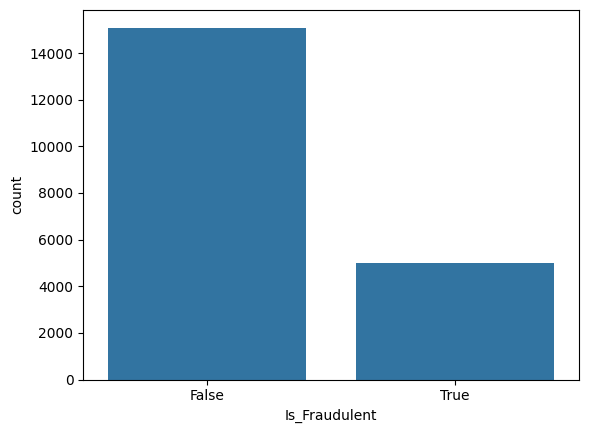

In [13]:
sns.countplot(x='Is_Fraudulent',data=df)
plt.show()

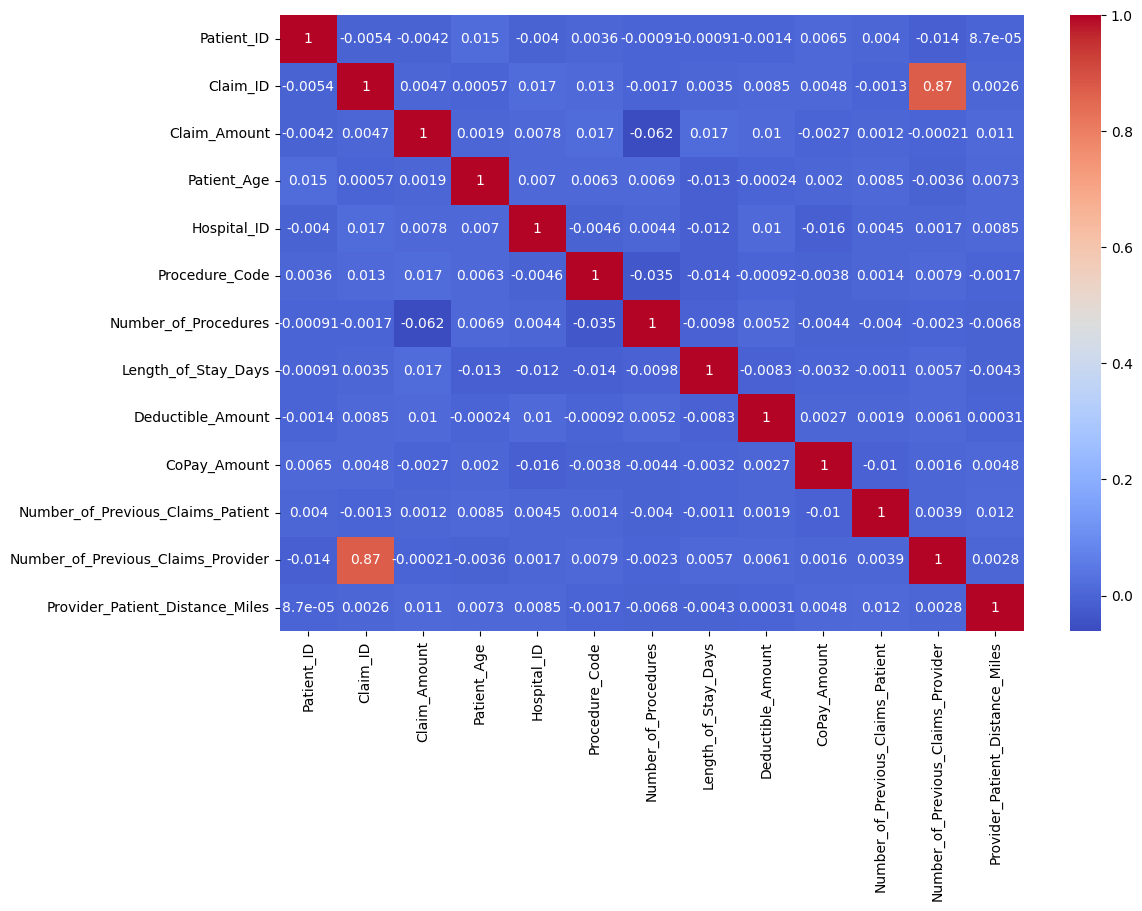

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

In [15]:
encoder=LabelEncoder()

for col in df.columns:

    if df[col].dtype=="object":
        df[col]=encoder.fit_transform(df[col])

In [16]:
X=df.drop('Is_Fraudulent',axis=1)

y=df['Is_Fraudulent']

In [17]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
pred_lr=lr.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_lr))

Accuracy: 0.75093399750934


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
pred_dt=dt.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_dt))

Accuracy: 0.8151930261519302


In [20]:
rf=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train,y_train)
pred_rf=rf.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred_rf))

Accuracy: 0.8729763387297634


In [21]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

       False       0.86      0.99      0.92      3015
        True       0.93      0.53      0.68      1000

    accuracy                           0.87      4015
   macro avg       0.90      0.76      0.80      4015
weighted avg       0.88      0.87      0.86      4015



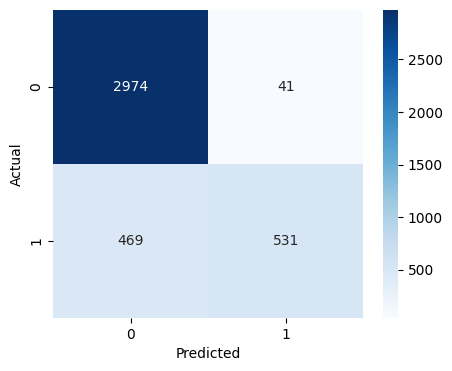

In [22]:
cm=confusion_matrix(y_test,pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

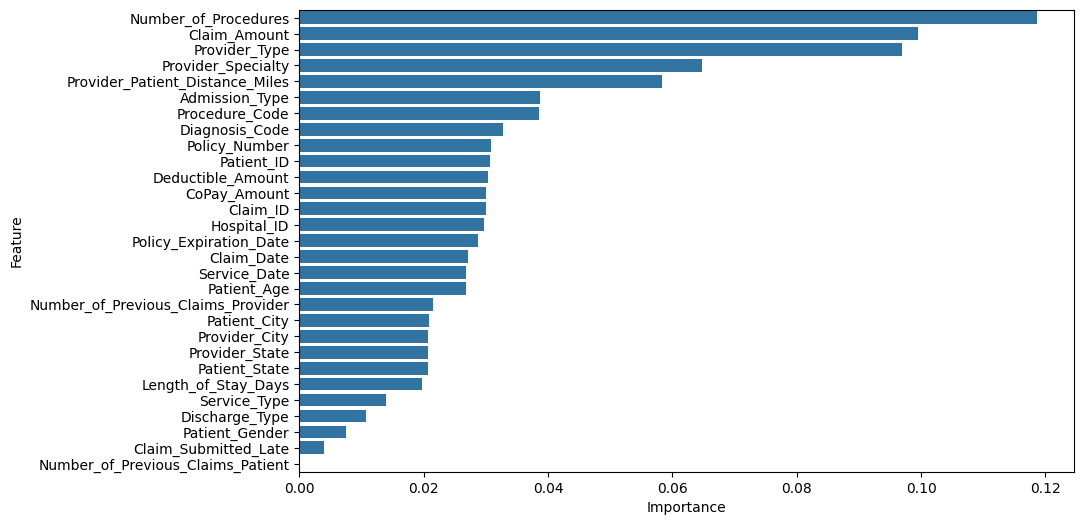

In [23]:
importance=rf.feature_importances_

features=pd.DataFrame({
    "Feature":X.columns,
    "Importance":importance
})

features=features.sort_values(by="Importance",ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=features
)

plt.show()

In [24]:
joblib.dump(rf,"insurance_fraud_model.pkl")

['insurance_fraud_model.pkl']

In [25]:
model=joblib.load("insurance_fraud_model.pkl")

In [26]:
sample=X.iloc[[0]]

prediction=model.predict(sample)

print(prediction)

[False]


In [27]:
from google.colab import files

files.download("insurance_fraud_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>